# Full dynamic parametric validation

This notebook belongs to the `dynamic/` branch of the repo. It runs the repeated synthetic validation for the Markov-IBP model, focuses the saved findings on effective-weight and observed-bias recovery, and keeps one representative replication for detailed inspection.


In [1]:
import os
import sys
from pathlib import Path
import json
import csv

cwd = Path.cwd().resolve()
repo_root = None
for candidate in (cwd, *cwd.parents):
    if (candidate / "dynamic" / "ifhmm.py").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing dynamic/ifhmm.py")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

from dynamic.ifhmm import DynamicIFHMMModel, DynamicIFHMMSampler

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)

OUTPUT_DIR = Path("outputs") / "dynamic_parametric_full"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MASTER_SEED = 11


## Setup

Define the study configuration, helper utilities, and single-replication routine used throughout the dynamic validation run.


In [2]:
# Study configuration
study_name = "dynamic_parametric_full"

# Data-generating parameters shared with validation_full.ipynb
T = 600
S = 4
K = 8
alpha = 4.0
rho = 0.3
sigma_w = 1.0
mu_b = [-3.0] * S
sigma_b = 1.0

# Dynamic parameters for the truncated mIBP transitions
gamma = 6.0
delta = 1.0

# Validation settings
replications = 10
chains = 4
n_iter = 2000
burn = 1000
n_subsample = 250
active_threshold = 5

print({
    "study_name": study_name,
    "T": T,
    "S": S,
    "K": K,
    "alpha": alpha,
    "gamma": gamma,
    "delta": delta,
    "rho": rho,
    "chains": chains,
    "n_iter": n_iter,
    "burn": burn,
    "n_subsample": n_subsample,
    "replications": replications,
})


{'study_name': 'dynamic_parametric_full', 'T': 600, 'S': 4, 'K': 8, 'alpha': 4.0, 'gamma': 6.0, 'delta': 1.0, 'rho': 0.3, 'chains': 4, 'n_iter': 2000, 'burn': 1000, 'n_subsample': 250, 'replications': 10}


In [3]:
def corrcoef_flat(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]


def mse(a, b):
    return np.mean((np.asarray(a) - np.asarray(b)) ** 2)


def summarize_intervals(samples, truth, level=0.9):
    alpha_tail = (1.0 - level) / 2.0
    low = np.quantile(samples, alpha_tail, axis=0)
    high = np.quantile(samples, 1.0 - alpha_tail, axis=0)
    covered = (truth >= low) & (truth <= high)
    width = np.mean(high - low)
    return {
        "mean": samples.mean(axis=0),
        "low": low,
        "high": high,
        "covered": covered,
        "mean_width": float(width),
    }


def align_single_sample(W_eff_sample, W_eff_target):
    cost = np.zeros((W_eff_target.shape[0], W_eff_sample.shape[0]))
    for i in range(W_eff_target.shape[0]):
        for j in range(W_eff_sample.shape[0]):
            cost[i, j] = np.linalg.norm(W_eff_target[i] - W_eff_sample[j])
    _, col_ind = linear_sum_assignment(cost)
    return col_ind


def align_chain_samples(Z_post, W_post, A_post, b_post, a_post, btrans_post, W_target):
    Z_aligned = Z_post.copy()
    W_aligned = W_post.copy()
    A_aligned = A_post.copy()
    b_aligned = b_post.copy()
    a_aligned = a_post.copy()
    btrans_aligned = btrans_post.copy()

    for draw in range(W_post.shape[0]):
        perm = align_single_sample(W_post[draw] * A_post[draw], W_target)
        Z_aligned[draw] = Z_post[draw][:, perm]
        W_aligned[draw] = W_post[draw][perm]
        A_aligned[draw] = A_post[draw][perm]
        a_aligned[draw] = a_post[draw][perm]
        btrans_aligned[draw] = btrans_post[draw][perm]

    return Z_aligned, W_aligned, A_aligned, b_aligned, a_aligned, btrans_aligned


def posterior_mean_activation_samples(Z_post):
    return Z_post.mean(axis=1)


def active_feature_count(Z_post, threshold):
    return np.sum(Z_post.sum(axis=1) > threshold, axis=1)


In [4]:
def run_single_replication(rep_id, base_seed):
    rng = np.random.default_rng(base_seed)
    truth_model = DynamicIFHMMModel(
        T=T,
        S=S,
        K=K,
        rho=rho,
        alpha=alpha,
        gamma=gamma,
        delta=delta,
        sigma_w=sigma_w,
        sigma_b=sigma_b,
        mu_b=mu_b,
        rng=rng,
    )
    Y = truth_model.sample_observations()
    truth_state = truth_model.state.copy()
    W_true = truth_state.effective_weights()
    b_true = truth_state.b.copy()
    a_true = truth_state.a.copy()
    btrans_true = truth_state.b_trans.copy()
    q_true = truth_state.Z.mean(axis=0)

    chain_results = []
    for chain in range(chains):
        np.random.seed(base_seed + 1000 + chain)
        sampler = DynamicIFHMMSampler(
            Data=Y,
            K=K,
            rho=rho,
            alpha=alpha,
            gamma=gamma,
            delta=delta,
            sigma_w=sigma_w,
            sigma_b=sigma_b,
            mu_b=mu_b,
            n_iter=n_iter,
            burn=burn,
            n_subsample=n_subsample,
        )
        sampler.run(verbose=False)
        sampler.get_posterior_samples()

        Z_post, W_post, A_post, b_post, a_post, btrans_post = align_chain_samples(
            sampler.good_samples_Z,
            sampler.good_samples_W,
            sampler.good_samples_A,
            sampler.good_samples_b,
            sampler.good_samples_a,
            sampler.good_samples_b_trans,
            W_true,
        )
        q_post = posterior_mean_activation_samples(Z_post)

        chain_results.append({
            "Z": Z_post,
            "W": W_post,
            "A": A_post,
            "b": b_post,
            "a": a_post,
            "b_trans": btrans_post,
            "q": q_post,
        })

    W_all = np.concatenate([chain["W"] for chain in chain_results], axis=0)
    A_all = np.concatenate([chain["A"] for chain in chain_results], axis=0)
    b_all = np.concatenate([chain["b"] for chain in chain_results], axis=0)
    a_all = np.concatenate([chain["a"] for chain in chain_results], axis=0)
    btrans_all = np.concatenate([chain["b_trans"] for chain in chain_results], axis=0)
    q_all = np.concatenate([chain["q"] for chain in chain_results], axis=0)
    W_eff_all = W_all * A_all

    W_eff_mean = W_eff_all.mean(axis=0)
    b_mean = b_all.mean(axis=0)
    a_mean = a_all.mean(axis=0)
    btrans_mean = btrans_all.mean(axis=0)
    q_mean = q_all.mean(axis=0)

    interval_W = summarize_intervals(W_eff_all, W_true)
    interval_b = summarize_intervals(b_all, b_true)
    interval_a = summarize_intervals(a_all, a_true)
    interval_btrans = summarize_intervals(btrans_all, btrans_true)
    interval_q = summarize_intervals(q_all, q_true)

    active_counts = np.concatenate([active_feature_count(chain["Z"], active_threshold) for chain in chain_results])

    metrics = {
        "replication": rep_id,
        "W_mse": float(mse(W_eff_mean, W_true)),
        "W_corr": float(corrcoef_flat(W_eff_mean, W_true)),
        "b_mse": float(mse(b_mean, b_true)),
        "b_corr": float(corrcoef_flat(b_mean, b_true)),
        "a_mse": float(mse(a_mean, a_true)),
        "a_corr": float(corrcoef_flat(a_mean, a_true)),
        "btrans_mse": float(mse(btrans_mean, btrans_true)),
        "btrans_corr": float(corrcoef_flat(btrans_mean, btrans_true)),
        "q_mse": float(mse(q_mean, q_true)),
        "q_corr": float(corrcoef_flat(q_mean, q_true)),
        "W_width90": interval_W["mean_width"],
        "b_width90": interval_b["mean_width"],
        "a_width90": interval_a["mean_width"],
        "btrans_width90": interval_btrans["mean_width"],
        "q_width90": interval_q["mean_width"],
        "active_features_mean": float(active_counts.mean()),
        "active_features_std": float(active_counts.std(ddof=1)) if active_counts.size > 1 else 0.0,
    }

    details = {
        "replication": rep_id,
        "truth": {
            "W_true": W_true.tolist(),
            "b_true": b_true.tolist(),
            "a_true": a_true.tolist(),
            "btrans_true": btrans_true.tolist(),
            "q_true": q_true.tolist(),
        },
        "posterior_mean": {
            "W_eff": W_eff_mean.tolist(),
            "b": b_mean.tolist(),
            "a": a_mean.tolist(),
            "b_trans": btrans_mean.tolist(),
            "q": q_mean.tolist(),
        },
        "intervals": {
            "W_eff": {
                "covered": interval_W["covered"].tolist(),
                "mean_width": interval_W["mean_width"],
            },
            "b": {
                "covered": interval_b["covered"].tolist(),
                "mean_width": interval_b["mean_width"],
            },
            "a": {
                "covered": interval_a["covered"].tolist(),
                "mean_width": interval_a["mean_width"],
            },
            "b_trans": {
                "covered": interval_btrans["covered"].tolist(),
                "mean_width": interval_btrans["mean_width"],
            },
            "q": {
                "covered": interval_q["covered"].tolist(),
                "mean_width": interval_q["mean_width"],
            },
        },
    }
    return metrics, details


In [5]:
replication_metrics = []
replication_details = []

for rep in range(replications):
    print(f"Running replication {rep + 1}/{replications}")
    metrics, details = run_single_replication(rep_id=rep, base_seed=MASTER_SEED + 100 * rep)
    replication_metrics.append(metrics)
    replication_details.append(details)

print("Finished all replications.")


Running replication 1/10
Running replication 2/10
Running replication 3/10
Running replication 4/10
Running replication 5/10
Running replication 6/10
Running replication 7/10
Running replication 8/10
Running replication 9/10
Running replication 10/10
Finished all replications.


## Aggregate recovery summaries

This section collapses the replication-level metrics into primary weight and bias recovery summaries, then packages one representative replication for the saved outputs.


In [6]:
primary_metric_names = [
    "W_mse", "W_corr", "b_mse", "b_corr",
    "W_width90", "b_width90",
    "active_features_mean", "active_features_std",
]

secondary_metric_names = [
    "a_mse", "a_corr", "btrans_mse", "btrans_corr", "q_mse", "q_corr",
    "a_width90", "btrans_width90", "q_width90",
]

metric_names = primary_metric_names + secondary_metric_names

summary = {}
for name in metric_names:
    values = np.array([row[name] for row in replication_metrics], dtype=float)
    summary[name] = {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)) if len(values) > 1 else 0.0,
        "min": float(values.min()),
        "max": float(values.max()),
        "median": float(np.median(values)),
    }

W_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["W_eff"]["covered"], dtype=float) for d in replication_details]), axis=0)
b_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["b"]["covered"], dtype=float) for d in replication_details]), axis=0)
a_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["a"]["covered"], dtype=float) for d in replication_details]), axis=0)
btrans_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["b_trans"]["covered"], dtype=float) for d in replication_details]), axis=0)
q_coverage_by_param = np.mean(np.stack([np.array(d["intervals"]["q"]["covered"], dtype=float) for d in replication_details]), axis=0)

coverage_summary = {
    "W": {"mean": float(W_coverage_by_param.mean()), "matrix": W_coverage_by_param.tolist()},
    "b": {"mean": float(b_coverage_by_param.mean()), "vector": b_coverage_by_param.tolist()},
    "a": {"mean": float(a_coverage_by_param.mean()), "vector": a_coverage_by_param.tolist()},
    "b_trans": {"mean": float(btrans_coverage_by_param.mean()), "vector": btrans_coverage_by_param.tolist()},
    "q": {"mean": float(q_coverage_by_param.mean()), "vector": q_coverage_by_param.tolist()},
}

print("Primary validation summary: weights and biases")
print("--------------------------------------------")
for name in primary_metric_names:
    s = summary[name]
    print(f"{name:24s} mean={s['mean']:.4f} std={s['std']:.4f} min={s['min']:.4f} max={s['max']:.4f}")

print("\nSecondary dynamic summaries: harder to estimate from a single dataset")
print("-------------------------------------------------------------------")
for name in secondary_metric_names:
    s = summary[name]
    print(f"{name:24s} mean={s['mean']:.4f} std={s['std']:.4f} min={s['min']:.4f} max={s['max']:.4f}")

print("\nMean 90% interval coverage")
print("-------------------------")
print(f"W        : {coverage_summary['W']['mean']:.4f}")
print(f"b        : {coverage_summary['b']['mean']:.4f}")
print(f"a        : {coverage_summary['a']['mean']:.4f}   <- secondary / hard to identify")
print(f"b_trans  : {coverage_summary['b_trans']['mean']:.4f}   <- secondary / hard to identify")
print(f"q        : {coverage_summary['q']['mean']:.4f}   <- descriptive occupancy summary")


Primary validation summary: weights and biases
--------------------------------------------
W_mse                    mean=0.0804 std=0.0630 min=0.0121 max=0.2040
W_corr                   mean=0.8552 std=0.0707 min=0.7571 max=0.9533
b_mse                    mean=0.4600 std=0.3070 min=0.0787 max=1.0444
b_corr                   mean=0.6860 std=0.4126 min=-0.3040 max=0.9837
W_width90                mean=1.1571 std=0.1269 min=0.9559 max=1.3460
b_width90                mean=2.2731 std=0.1731 min=2.0347 max=2.6269
active_features_mean     mean=7.6264 std=0.2375 min=7.2260 max=7.9400
active_features_std      mean=0.5222 std=0.1859 min=0.2376 max=0.7922

Secondary dynamic summaries: harder to estimate from a single dataset
-------------------------------------------------------------------
a_mse                    mean=0.0843 std=0.0245 min=0.0540 max=0.1286
a_corr                   mean=0.1941 std=0.1790 min=-0.0837 max=0.5096
btrans_mse               mean=0.0167 std=0.0086 min=0.0040 max=0.03

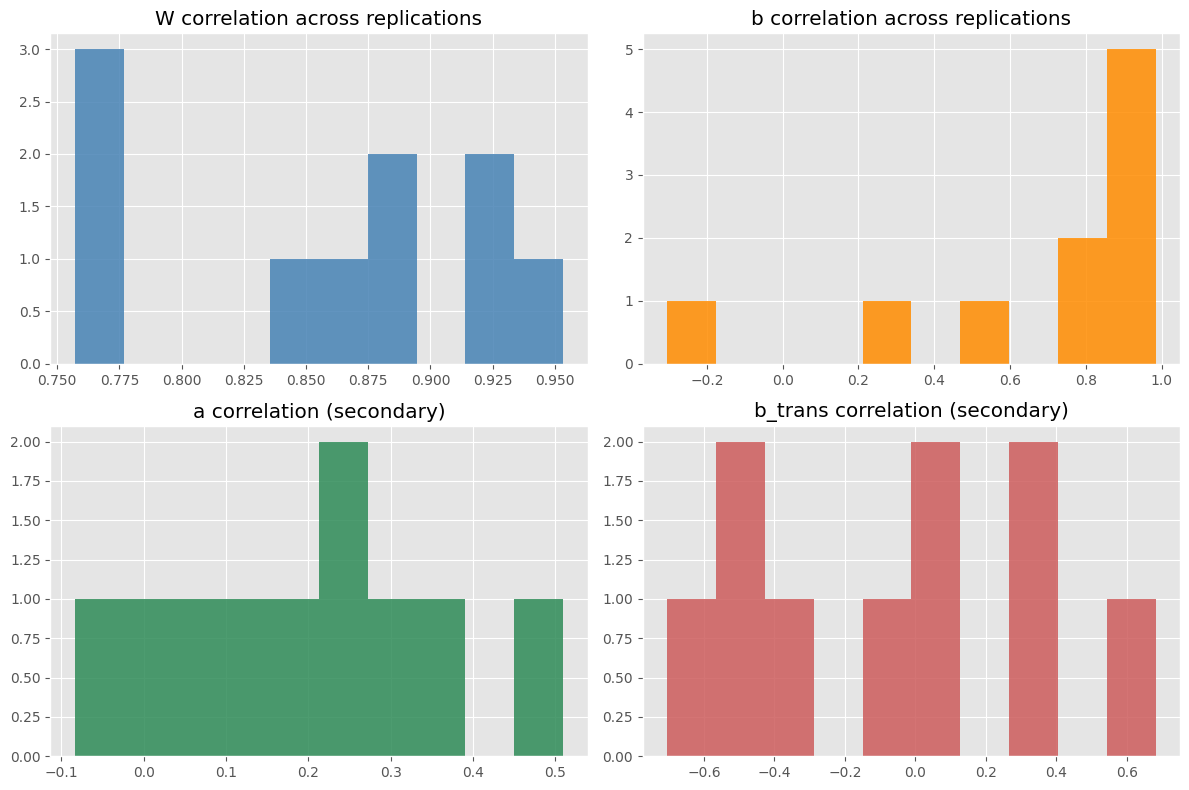

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist([row["W_corr"] for row in replication_metrics], bins=10, color="steelblue", alpha=0.85)
axes[0, 0].set_title("W correlation across replications")

axes[0, 1].hist([row["b_corr"] for row in replication_metrics], bins=10, color="darkorange", alpha=0.85)
axes[0, 1].set_title("b correlation across replications")

axes[1, 0].hist([row["a_corr"] for row in replication_metrics], bins=10, color="seagreen", alpha=0.85)
axes[1, 0].set_title("a correlation (secondary)")

axes[1, 1].hist([row["btrans_corr"] for row in replication_metrics], bins=10, color="indianred", alpha=0.85)
axes[1, 1].set_title("b_trans correlation (secondary)")

fig.tight_layout()
plt.show()


## Representative replication and exports

Select one representative replication, then write the aggregate findings and detailed recovery summaries to the validation output folder.


In [9]:
representative_idx = int(np.argmin(np.abs(np.array([row["W_corr"] for row in replication_metrics]) - np.median([row["W_corr"] for row in replication_metrics]))))
representative_metrics = replication_metrics[representative_idx]
representative_details = replication_details[representative_idx]

main_findings = {
    "study_name": study_name,
    "configuration": {
        "T": T,
        "S": S,
        "K": K,
        "alpha": alpha,
        "gamma": gamma,
        "delta": delta,
        "rho": rho,
        "chains": chains,
        "n_iter": n_iter,
        "burn": burn,
        "n_subsample": n_subsample,
        "replications": replications,
    },
    "summary": summary,
    "coverage_summary": coverage_summary,
    "headline": {
        "share_W_corr_ge_0.7": float(np.mean([row["W_corr"] >= 0.7 for row in replication_metrics])),
        "share_b_corr_ge_0.7": float(np.mean([row["b_corr"] >= 0.7 for row in replication_metrics])),
    },
    "representative_replication": {
        "index": representative_idx,
        "metrics": representative_metrics,
        "truth": representative_details["truth"],
        "posterior_mean": representative_details["posterior_mean"],
        "intervals": representative_details["intervals"],
        "recovery_delta": {
            "W_eff_minus_true": (
                np.array(representative_details["posterior_mean"]["W_eff"]) - np.array(representative_details["truth"]["W_true"])
            ).tolist(),
            "b_minus_true": (
                np.array(representative_details["posterior_mean"]["b"]) - np.array(representative_details["truth"]["b_true"])
            ).tolist(),
            "a_minus_true": (
                np.array(representative_details["posterior_mean"]["a"]) - np.array(representative_details["truth"]["a_true"])
            ).tolist(),
            "b_trans_minus_true": (
                np.array(representative_details["posterior_mean"]["b_trans"]) - np.array(representative_details["truth"]["btrans_true"])
            ).tolist(),
            "q_minus_true": (
                np.array(representative_details["posterior_mean"]["q"]) - np.array(representative_details["truth"]["q_true"])
            ).tolist(),
        },
    },
}

print("Representative replication index:", representative_idx)
print(json.dumps(main_findings["headline"], indent=2))


Representative replication index: 7
{
  "share_W_corr_ge_0.7": 1.0,
  "share_b_corr_ge_0.7": 0.7
}


In [11]:
csv_path = OUTPUT_DIR / f"{study_name}_metrics.csv"
json_path = OUTPUT_DIR / f"{study_name}_summary.json"
details_path = OUTPUT_DIR / f"{study_name}_replications.json"
txt_path = OUTPUT_DIR / f"{study_name}_findings.txt"

fieldnames = list(replication_metrics[0].keys())
with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(replication_metrics)

with json_path.open("w") as f:
    json.dump(main_findings, f, indent=2)

with details_path.open("w") as f:
    json.dump(replication_details, f, indent=2)

with txt_path.open("w") as f:
    f.write(f"Study: {study_name}\n")
    f.write("Configuration:\n")
    for key, value in main_findings["configuration"].items():
        f.write(f"  {key}: {value}\n")
    f.write("\nHeadline findings:\n")
    f.write(f"  Share of replications with W correlation >= 0.7: {main_findings['headline']['share_W_corr_ge_0.7']:.4f}\n")
    f.write(f"  Share of replications with b correlation >= 0.7: {main_findings['headline']['share_b_corr_ge_0.7']:.4f}\n")
    f.write("\nInterpretation note:\n")
    f.write("  The main estimation targets are the effective weights W_eff and the observed-dimension biases b.\n")
    f.write("  The dynamic probabilities a and b_trans are not directly observed and are harder to identify from a single dataset,\n")
    f.write("  so they are reported only as secondary summaries. The empirical mean activation q is descriptive rather than primary.\n")
    f.write("\nPrimary mean-recovery metrics (weights and biases):\n")
    for name in ["W_mse", "W_corr", "b_mse", "b_corr", "W_width90", "b_width90"]:
        s = summary[name]
        f.write(f"  {name}: mean={s['mean']:.4f}, std={s['std']:.4f}, min={s['min']:.4f}, max={s['max']:.4f}, median={s['median']:.4f}\n")
    f.write("\nSecondary dynamic summaries:\n")
    for name in ["a_mse", "a_corr", "btrans_mse", "btrans_corr", "q_mse", "q_corr", "a_width90", "btrans_width90", "q_width90"]:
        s = summary[name]
        f.write(f"  {name}: mean={s['mean']:.4f}, std={s['std']:.4f}, min={s['min']:.4f}, max={s['max']:.4f}, median={s['median']:.4f}\n")
    f.write("\nPer-parameter mean interval coverage:\n")
    f.write(f"  W: {coverage_summary['W']['mean']:.4f}\n")
    f.write(f"  b: {coverage_summary['b']['mean']:.4f}\n")
    f.write(f"  a: {coverage_summary['a']['mean']:.4f}\n")
    f.write(f"  b_trans: {coverage_summary['b_trans']['mean']:.4f}\n")
    f.write(f"  q: {coverage_summary['q']['mean']:.4f}\n")

    rep = main_findings["representative_replication"]
    f.write(f"\nRepresentative replication: {rep['index']}\n")
    f.write("Representative metrics:\n")
    for key, value in rep["metrics"].items():
        if key == "replication":
            continue
        f.write(f"  {key}: {value:.4f}\n" if isinstance(value, float) else f"  {key}: {value}\n")
    f.write("\nRepresentative true parameters:\n")
    f.write(f"  W_true:\n{np.array2string(np.array(rep['truth']['W_true']), precision=3)}\n")
    f.write(f"  b_true:\n{np.array2string(np.array(rep['truth']['b_true']), precision=3)}\n")
    f.write(f"  a_true:\n{np.array2string(np.array(rep['truth']['a_true']), precision=3)}\n")
    f.write(f"  b_trans_true:\n{np.array2string(np.array(rep['truth']['btrans_true']), precision=3)}\n")
    f.write(f"  q_true:\n{np.array2string(np.array(rep['truth']['q_true']), precision=3)}\n")
    f.write("\nRepresentative posterior means:\n")
    f.write(f"  W_eff_mean:\n{np.array2string(np.array(rep['posterior_mean']['W_eff']), precision=3)}\n")
    f.write(f"  b_mean:\n{np.array2string(np.array(rep['posterior_mean']['b']), precision=3)}\n")
    f.write(f"  a_mean:\n{np.array2string(np.array(rep['posterior_mean']['a']), precision=3)}\n")
    f.write(f"  b_trans_mean:\n{np.array2string(np.array(rep['posterior_mean']['b_trans']), precision=3)}\n")
    f.write(f"  q_mean:\n{np.array2string(np.array(rep['posterior_mean']['q']), precision=3)}\n")
    f.write("\nRepresentative recovery deltas (posterior mean minus truth):\n")
    f.write(f"  W_eff_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['W_eff_minus_true']), precision=3)}\n")
    f.write(f"  b_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['b_minus_true']), precision=3)}\n")
    f.write(f"  a_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['a_minus_true']), precision=3)}\n")
    f.write(f"  b_trans_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['b_trans_minus_true']), precision=3)}\n")
    f.write(f"  q_minus_true:\n{np.array2string(np.array(rep['recovery_delta']['q_minus_true']), precision=3)}\n")

print({
    "csv": str(csv_path),
    "json": str(json_path),
    "details": str(details_path),
    "txt": str(txt_path),
})


{'csv': 'outputs/dynamic_parametric_full/dynamic_parametric_full_metrics.csv', 'json': 'outputs/dynamic_parametric_full/dynamic_parametric_full_summary.json', 'details': 'outputs/dynamic_parametric_full/dynamic_parametric_full_replications.json', 'txt': 'outputs/dynamic_parametric_full/dynamic_parametric_full_findings.txt'}
